# 05 - Where the Model Fails

We now have a model. One XGBoost for each store segment scores **0.1451**,
against 0.1497 for a single global model and 0.1664 for the baseline.

The next step is to add features. But which features? A long list of ideas is
easy to write and expensive to test, and most ideas on such a list do nothing.
Notebook 03 already showed this. We found a clean pattern in the raw data, built
two features for it, and gained nothing at all.

So this notebook does not guess. It takes the model we have, keeps every scored
row, and asks where the error sits. Is it spread over all stores, or does a
small group carry it? Which segment is the weakest? Which days?

Every answer has to name a feature. At the end there is a ranked list of the
weak spots, and each item says what we would build for it. That list, and not
our imagination, chooses the work of the next notebook.


In [1]:
import sys
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.features import FeatureBuilder
from src.model import SalesModel, DEFAULT_PARAMS
from src.segments import StoreSegmenter
from src.validation import RollingOriginSplit
from src.metrics import rmspe

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pl.Config.set_tbl_rows(20)

df = DataLoader(PROJECT_ROOT / "data").load()
folds = list(RollingOriginSplit(n_splits=4).split(df))
print("Rows:  ", f"{df.height:,}")
print("Stores:", df["Store"].n_unique())


Rows:   844,392
Stores: 1115


## The rows we study

We run the winning model again and keep every scored row.

Two things are worth saying about the setup.

**We run the global model at the same time.** For each window we fit the
features and the segments once, and then train both the global model and the
four segment models on exactly the same input. This costs little and it buys a
lot. For every group below we can see not only the error of our model, but also
whether splitting the data helped that group or hurt it.

**We use three seeds.** The model draws 80 percent of the columns for each tree,
so a single run moves by a few thousandths. Notebook 04 made this a rule: no
number that we compare may come from one seed. It matters even more here,
because some groups below are small, and a small group moves more.

The next cell trains 12 pairs of models. It takes a few minutes.


In [2]:
SEGMENTS = [1, 2, 3, 4]
SEEDS = [42, 7, 2024]
KEEP = ["Store", "Date", "DayOfWeek", "Sales", "Promo", "SchoolHoliday",
        "StateHoliday", "StoreType", "Assortment", "segment",
        "prediction", "pred_global"]


def score_fold(train, valid, seed):
    """Train both models on one fold and return the scored validation rows.

    The feature builder and the segmenter are fitted on the training rows of the
    fold only. Both models then see the same features and the same segment
    labels, so a difference between the two prediction columns comes from the
    shape of the model and from nothing else.
    """
    params = dict(DEFAULT_PARAMS, seed=seed)
    builder = FeatureBuilder().fit(train)
    segmenter = StoreSegmenter(n_segments=4).fit(train)
    tr = segmenter.transform(builder.transform(train))
    va = segmenter.transform(builder.transform(valid))

    whole = SalesModel(params=params).fit(tr, builder.feature_names_)
    va = va.with_columns(pl.Series("pred_global", whole.predict(va)))

    parts = []
    for s in SEGMENTS:
        tr_s, va_s = tr.filter(pl.col("segment") == s), va.filter(pl.col("segment") == s)
        if va_s.height == 0:
            continue
        model = SalesModel(params=params).fit(tr_s, builder.feature_names_)
        parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
    return pl.concat(parts).select(KEEP)


In [3]:
frames = []
for seed in SEEDS:
    for fold in folds:
        out = score_fold(fold.train, fold.valid, seed)
        frames.append(out.with_columns(pl.lit(seed).alias("seed"),
                                       pl.lit(fold.index).alias("fold")))
        print(f"seed {seed}, fold {fold.index}: "
              f"per segment {rmspe(out['Sales'], out['prediction']):.4f}   "
              f"global {rmspe(out['Sales'], out['pred_global']):.4f}")

scored = pl.concat(frames)
print(f"\nScored rows: {scored.height:,}")


seed 42, fold 1: per segment 0.1769   global 0.1806


seed 42, fold 2: per segment 0.1440   global 0.1464


seed 42, fold 3: per segment 0.1264   global 0.1305


seed 42, fold 4: per segment 0.1333   global 0.1315


seed 7, fold 1: per segment 0.1756   global 0.1796


...

seed 7, fold 4: per segment 0.1361   global 0.1379


seed 2024, fold 1: per segment 0.1752   global 0.1783


seed 2024, fold 2: per segment 0.1447   global 0.1559


seed 2024, fold 3: per segment 0.1254   global 0.1312


seed 2024, fold 4: per segment 0.1342   global 0.1397

Scored rows: 464,925


Two small helpers do all the grouping below.

`by` gives the error of every group. It scores each seed on its own and then
averages, and it also reports the spread over the seeds. When that spread is as
large as the difference we are looking at, the difference is noise.

`both` puts the two models side by side. A negative `delta` means the segmented
model is the better one on that group.

Please read the `rows` column every time. A group of a few hundred rows can show
a large error that means nothing.

One line needs a word of explanation. A handful of rows are open days with zero
sales. RMSPE divides by the real sales, so those rows cannot be scored, and we
drop them here in the same way `rmspe` does.


In [4]:
zero_sales = scored.filter(pl.col("Sales") == 0).height
scored = scored.filter(pl.col("Sales") != 0)
print(f"Open days with zero sales, dropped: {zero_sales}")

# The squared percentage error of every row. Every table below is built from
# this column, because RMSPE is the square root of its mean.
scored = scored.with_columns(
    (((pl.col("Sales") - pl.col("prediction")) / pl.col("Sales")) ** 2).alias("sq"),
    ((pl.col("prediction") - pl.col("Sales")) / pl.col("Sales")).alias("rel"))


def by(frame, cols, pred="prediction"):
    """RMSPE per group, averaged over the three seeds.

    We score each seed on its own and then average the scores. This keeps one
    unlucky run from moving a small group, and the spread over the seeds tells
    us how far we may trust the number.
    """
    cols = [cols] if isinstance(cols, str) else list(cols)
    per_seed = (
        frame.with_columns(
            (((pl.col("Sales") - pl.col(pred)) / pl.col("Sales")) ** 2).alias("_sq"))
        .group_by(cols + ["seed"])
        .agg(pl.col("_sq").mean().sqrt().alias("_r"), pl.len().alias("rows"))
    )
    return (per_seed.group_by(cols)
            .agg(pl.col("_r").mean().round(4).alias("rmspe"),
                 pl.col("_r").std(ddof=0).round(4).alias("seed_sd"),
                 pl.col("rows").mean().cast(pl.Int64).alias("rows"))
            .sort(cols))


def both(frame, cols):
    """The same table for the two models, with the difference between them.

    A negative `delta` means the segmented model is better on that group.
    """
    cols = [cols] if isinstance(cols, str) else list(cols)
    a = by(frame, cols, "prediction").rename({"rmspe": "segmented"}).drop("seed_sd")
    g = by(frame, cols, "pred_global").rename({"rmspe": "global"}).drop(["seed_sd", "rows"])
    return (a.join(g, on=cols)
            .with_columns((pl.col("segmented") - pl.col("global")).round(4).alias("delta"))
            .select(cols + ["rows", "global", "segmented", "delta"])
            .sort(cols))


print(both(scored, "fold"))
print(f"\nmean over the four windows: "
      f"global {by(scored, 'fold', 'pred_global')['rmspe'].mean():.4f}, "
      f"segmented {by(scored, 'fold')['rmspe'].mean():.4f}")


Open days with zero sales, dropped: 6
shape: (4, 5)
┌──────┬───────┬────────┬───────────┬─────────┐
│ fold ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---  ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ i32  ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞══════╪═══════╪════════╪═══════════╪═════════╡
│ 1    ┆ 40175 ┆ 0.1795 ┆ 0.1759    ┆ -0.0036 │
│ 2    ┆ 37044 ┆ 0.1523 ┆ 0.1441    ┆ -0.0082 │
│ 3    ┆ 37472 ┆ 0.1305 ┆ 0.126     ┆ -0.0045 │
│ 4    ┆ 40282 ┆ 0.1364 ┆ 0.1345    ┆ -0.0019 │
└──────┴───────┴────────┴───────────┴─────────┘



mean over the four windows: global 0.1497, segmented 0.1451


The numbers match what notebook 04 reported: **0.1451** for the segmented model
and **0.1497** for the global one, with the segmented model ahead on all four
windows. We are studying the right model.

The window that ends in March is still the hard one, 0.1759 against 0.1260 for
the window that ends in June. Question 2 below is about that gap.


## Question 1: is the error broad, or is it concentrated?

This is the first question, because the answer decides what kind of feature can
help us.

If a few hundred stores carry most of the error, those stores are a separate
problem, and we should look for what they have in common. If instead a few
single days carry it, then the problem is not the stores at all, and no store
feature will save us.

So we ask the question twice: once over the stores, and once over the days.


In [5]:
def concentration(frame, key):
    """Sort the groups by the error they produce and return the running share."""
    table = (frame.group_by(key)
             .agg(pl.col("sq").sum().alias("total"),
                  pl.col("sq").mean().sqrt().round(4).alias("rmspe"),
                  (pl.len() / len(SEEDS)).cast(pl.Int64).alias("rows"))
             .sort("total", descending=True))
    share = table["total"].to_numpy().cumsum() / table["total"].sum()
    return table, share


store_table, store_share = concentration(scored, "Store")
print(f"There are {store_table.height} stores.")
for pct in [1, 5, 10, 20, 50]:
    k = max(1, round(store_table.height * pct / 100))
    print(f"  the worst {pct:>2}% of them ({k:>4} stores) carry "
          f"{100 * store_share[k - 1]:.1f}% of the squared error")

day_table, day_share = concentration(scored, "Date")
print(f"\nThere are {day_table.height} validation days.")
for k in [1, 2, 5, 10, 20]:
    print(f"  the worst {k:>2} days carry {100 * day_share[k - 1]:.1f}% of the squared error")

print("\nThe ten days that carry the most error")
print(day_table.head(10))


There are 1115 stores.
  the worst  1% of them (  11 stores) carry 10.8% of the squared error
  the worst  5% of them (  56 stores) carry 23.4% of the squared error
  the worst 10% of them ( 112 stores) carry 33.0% of the squared error
  the worst 20% of them ( 223 stores) carry 45.7% of the squared error
  the worst 50% of them ( 558 stores) carry 71.9% of the squared error

There are 168 validation days.
  the worst  1 days carry 14.2% of the squared error
  the worst  2 days carry 18.3% of the squared error
  the worst  5 days carry 28.2% of the squared error
  the worst 10 days carry 36.4% of the squared error
  the worst 20 days carry 47.4% of the squared error

The ten days that carry the most error
shape: (10, 4)
┌────────────┬─────────────┬────────┬──────┐
│ Date       ┆ total       ┆ rmspe  ┆ rows │
│ ---        ┆ ---         ┆ ---    ┆ ---  │
│ date       ┆ f64         ┆ f64    ┆ i64  │
╞════════════╪═════════════╪════════╪══════╡
│ 2015-02-16 ┆ 1419.064733 ┆ 0.6609 ┆ 1083 │


In [6]:
per_store_fold = (scored.group_by(["fold", "Store"])
                  .agg(pl.col("sq").mean().sqrt().alias("rmspe"))
                  .pivot(on="fold", index="Store", values="rmspe")
                  .sort("Store"))
fold_cols = [c for c in per_store_fold.columns if c != "Store"]

print("Is a weak store weak in every window?")
values = per_store_fold.select(fold_cols).to_numpy()
for i in range(len(fold_cols)):
    for j in range(i + 1, len(fold_cols)):
        ok = ~np.isnan(values[:, i]) & ~np.isnan(values[:, j])
        r = np.corrcoef(values[ok, i], values[ok, j])[0, 1]
        print(f"  window {fold_cols[i]} and window {fold_cols[j]}: correlation {r:+.3f}")


Is a weak store weak in every window?
  window 4 and window 3: correlation +0.208
  window 4 and window 2: correlation +0.136
  window 4 and window 1: correlation +0.119
  window 3 and window 2: correlation +0.309
  window 3 and window 1: correlation +0.093
  window 2 and window 1: correlation +0.077


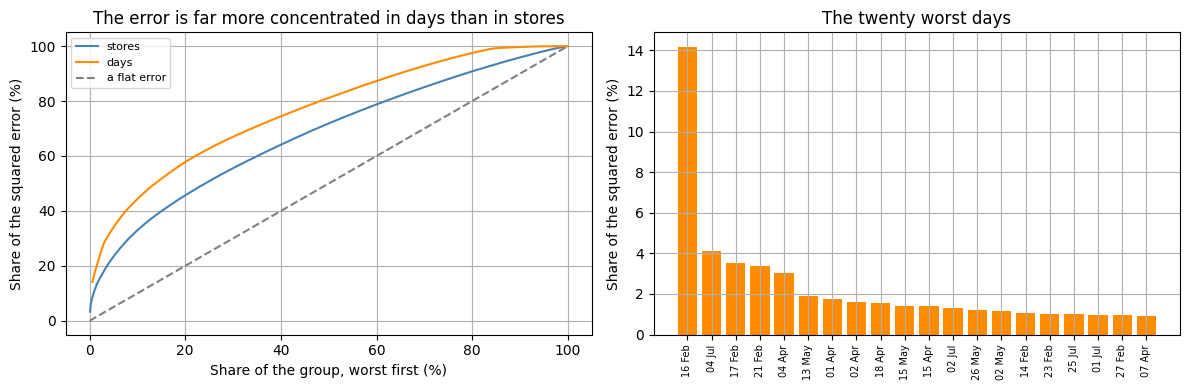

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(100 * np.arange(1, store_table.height + 1) / store_table.height,
             100 * store_share, color="steelblue", label="stores")
axes[0].plot(100 * np.arange(1, day_table.height + 1) / day_table.height,
             100 * day_share, color="darkorange", label="days")
axes[0].plot([0, 100], [0, 100], color="gray", linestyle="--", label="a flat error")
axes[0].set_xlabel("Share of the group, worst first (%)")
axes[0].set_ylabel("Share of the squared error (%)")
axes[0].set_title("The error is far more concentrated in days than in stores")
axes[0].legend(fontsize=8)

top = day_table.head(20)
axes[1].bar(range(top.height), 100 * top["total"].to_numpy() / day_table["total"].sum(),
            color="darkorange")
axes[1].set_xticks(range(top.height))
axes[1].set_xticklabels([d.strftime("%d %b") for d in top["Date"].to_list()],
                        rotation=90, fontsize=7)
axes[1].set_ylabel("Share of the squared error (%)")
axes[1].set_title("The twenty worst days")

plt.tight_layout()
plt.show()


This is the most important table in the notebook, and it is the second half
that matters.

**Over the stores the error is only mildly concentrated.** The worst 10 percent
of the stores carry 33 percent of the squared error. That is more than their
share, but it is not a small broken group: half of the stores are still needed
to reach 72 percent.

**Over the days it is very concentrated.** There are 168 validation days in
total. **The worst day alone carries 14.2 percent of the squared error, and the
worst ten days carry 36.4 percent.**

Those two lines point in different directions, and the second one is much
stronger. It says the model is not failing on a certain kind of *store*. It is
failing on a certain kind of *day*.

The correlation between the folds says the same thing. If some stores were
simply hard, a store with a large error in one window would have a large error
in the next one. The correlation between the windows is only +0.08 to +0.31, so
a store that fails in March is mostly fine in June.

That result changes the plan for the rest of the notebook. We keep asking the
store questions, because they were on our list and they are cheap, but the days
now come first.


## Question 2: what happens on the bad days?

The window that ends in March is the hardest one for every model we have built:
0.1877 for the baseline, 0.1806 for the global model, 0.1759 for the segmented
one. Notebook 02 tested two explanations and rejected both. It is not the length
of the training history, and it is not the renovated stores. What was left was
"the season itself", which is a name and not an explanation.

We can do better now, because we have the scored rows. First we look at the six
weeks of each window one by one, and then at the single days that carry the most
error.


In [8]:
window_week = scored.with_columns(
    ((pl.col("Date") - pl.col("Date").min().over("fold")).dt.total_days() // 7 + 1)
    .alias("week_in_window"))
print("Each week of each window")
print(by(window_week, ["fold", "week_in_window"])
      .pivot(on="fold", index="week_in_window", values="rmspe")
      .sort("week_in_window"))


Each week of each window
shape: (6, 5)
┌────────────────┬────────┬────────┬────────┬────────┐
│ week_in_window ┆ 1      ┆ 2      ┆ 3      ┆ 4      │
│ ---            ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ i64            ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞════════════════╪════════╪════════╪════════╪════════╡
│ 1              ┆ 0.3174 ┆ 0.1713 ┆ 0.1648 ┆ 0.1145 │
│ 2              ┆ 0.1826 ┆ 0.1795 ┆ 0.0924 ┆ 0.1461 │
│ 3              ┆ 0.1106 ┆ 0.147  ┆ 0.1309 ┆ 0.1853 │
│ 4              ┆ 0.1141 ┆ 0.1347 ┆ 0.1396 ┆ 0.108  │
│ 5              ┆ 0.1136 ┆ 0.113  ┆ 0.1183 ┆ 0.11   │
│ 6              ┆ 0.1175 ┆ 0.1115 ┆ 0.1061 ┆ 0.1264 │
└────────────────┴────────┴────────┴────────┴────────┘


In [9]:
for index in [1, 2, 3, 4]:
    part = scored.filter(pl.col("fold") == index)
    worst = (part.group_by("Date")
             .agg(pl.col("sq").sum().alias("total"),
                  pl.col("sq").mean().sqrt().round(3).alias("rmspe"),
                  (pl.col("rel").mean() * 100).round(1).alias("mean_rel_pct"))
             .with_columns((pl.col("total") / part["sq"].sum() * 100).round(1)
                           .alias("share_of_window_pct"))
             .sort("total", descending=True).head(4))
    print(f"window {index}: the days that carry the most error")
    print(worst.select(["Date", "rmspe", "mean_rel_pct", "share_of_window_pct"]))
    two = worst["Date"].to_list()[:2]
    rest = part.filter(~pl.col("Date").is_in(two))
    print(f"  window RMSPE {np.sqrt(part['sq'].mean()):.4f}"
          f"  ->  {np.sqrt(rest['sq'].mean()):.4f} without those two days\n")


window 1: the days that carry the most error
shape: (4, 4)
┌────────────┬───────┬──────────────┬─────────────────────┐
│ Date       ┆ rmspe ┆ mean_rel_pct ┆ share_of_window_pct │
│ ---        ┆ ---   ┆ ---          ┆ ---                 │
│ date       ┆ f64   ┆ f64          ┆ f64                 │
╞════════════╪═══════╪══════════════╪═════════════════════╡
│ 2015-02-16 ┆ 0.661 ┆ 16.7         ┆ 38.0                │
│ 2015-02-17 ┆ 0.324 ┆ 7.9          ┆ 9.4                 │
│ 2015-02-21 ┆ 0.319 ┆ 0.7          ┆ 9.1                 │
│ 2015-02-14 ┆ 0.179 ┆ -4.6         ┆ 2.9                 │
└────────────┴───────┴──────────────┴─────────────────────┘
  window RMSPE 0.1759  ->  0.1312 without those two days

window 2: the days that carry the most error
shape: (4, 4)
┌────────────┬───────┬──────────────┬─────────────────────┐
│ Date       ┆ rmspe ┆ mean_rel_pct ┆ share_of_window_pct │
│ ---        ┆ ---   ┆ ---          ┆ ---                 │
│ date       ┆ f64   ┆ f64          ┆ f64   

Now we can name it.

**Two days explain most of the hardest window.** The 16th and 17th of February
2015 are 5.5 percent of the rows of that window and carry **47 percent** of its
squared error. Without those two days the window scores 0.1312 instead of
0.1769, which would make it the *second easiest* of the four instead of the
hardest by far.

So the answer to "why is spring harder" is not a season. It is a small number of
days.

The table of the worst days shows what kind of days they are, and the
`mean_rel_pct` column shows the direction of the mistake. A negative number
means we predicted too low.

- **2015-04-02, 2015-04-04, 2015-04-01**: the days around Easter. Good Friday
  and Easter Monday are closed, so the Saturday between them is the only open
  day in a four day block. People buy for the whole block on that day. We
  predict **28 percent too low**.
- **2015-05-13, 2015-05-15, 2015-05-26**: the day before Ascension Day, the day
  after it, and the day after Whit Monday. All three are closed public holidays,
  and all three neighbours are predicted 17 to 23 percent too low.
- **2015-02-16 and 2015-02-17**: Rosenmontag and the Tuesday after it, the two
  carnival days. Here the mistake goes the other way. We predict **17 percent
  too high**.
- **2015-07-04** is the second worst day of the whole validation set, predicted
  **30 percent too high**. It is a Saturday with no promotion and no holiday
  near it, and nothing in our data explains it. We record it and leave it open.
  Two more Saturdays, 04-18 and 07-25, are also predicted too high.

There is a clear line through most of this. **The model does not know that a
closed day is coming, or that one has just passed.** It has `StateHoliday` for
the day itself, but a holiday is a closed day, and closed days are not in our
data at all. The days that carry the demand of the holiday are exactly the days
we get wrong.

The next cell measures that directly, without picking any dates by hand.


In [10]:
# The closed days were dropped from the model data, so we read the calendar
# again with them. We only use it to say which open day sits next to a closed
# one, and how far the closest state holiday is. Both are known six weeks in
# advance, so both would be allowed as features.
calendar = (DataLoader(PROJECT_ROOT / "data").load(drop_closed=False)
            .select(["Store", "Date", "Open", "StateHoliday"]).sort(["Store", "Date"]))
neighbours = calendar.with_columns(
    pl.col("Open").shift(1).over("Store").alias("open_yesterday"),
    pl.col("Open").shift(-1).over("Store").alias("open_tomorrow"),
).select(["Store", "Date", "open_yesterday", "open_tomorrow"])


def days_to_holiday(stores, dates, holidays):
    """How many days lie between each row and the closest state holiday.

    We take it per store, because the German states do not keep the same
    holidays.
    """
    stores, out = np.asarray(stores), None
    dates = np.asarray(dates, dtype="datetime64[D]")
    out = np.full(len(stores), 99, dtype=int)
    for store in np.unique(stores):
        days = holidays.get(int(store))
        if days is None:
            continue
        mask = stores == store
        here = dates[mask]
        position = np.searchsorted(days, here)
        before = days[np.clip(position - 1, 0, len(days) - 1)]
        after = days[np.clip(position, 0, len(days) - 1)]
        out[mask] = np.minimum(np.abs((here - before).astype(int)),
                               np.abs((after - here).astype(int)))
    return out


holiday_days = {}
for key, part in (calendar.filter(pl.col("StateHoliday") != "0")
                  .select(["Store", "Date"]).unique().sort(["Store", "Date"])
                  .group_by("Store")):
    store = key[0] if isinstance(key, tuple) else key
    holiday_days[store] = np.sort(part["Date"].to_numpy().astype("datetime64[D]"))

# The place of the day inside its promotion block: 1 is the first day.
runs = df.select(["Store", "Date", "Promo"]).sort(["Store", "Date"])
runs = runs.with_columns(
    (pl.col("Promo") != pl.col("Promo").shift(1).over("Store")).fill_null(True).alias("_new"))
runs = runs.with_columns(pl.col("_new").cum_sum().over("Store").alias("_run"))
runs = runs.with_columns(pl.col("Promo").cum_count().over(["Store", "_run"]).alias("promo_day"))

context = (scored
           .join(neighbours, on=["Store", "Date"], how="left")
           .join(runs.select(["Store", "Date", "promo_day"]), on=["Store", "Date"], how="left"))
context = context.with_columns(pl.Series("holiday_gap", days_to_holiday(
    context["Store"].to_numpy(), context["Date"].to_numpy(), holiday_days)))

print(both(context.with_columns(
    pl.when(pl.col("open_yesterday") == 0).then(pl.lit("after a closed day"))
    .when(pl.col("open_tomorrow") == 0).then(pl.lit("before a closed day"))
    .otherwise(pl.lit("a normal day")).alias("closure")), "closure"))

print("\nDays to the closest state holiday of that store")
print(by(context.with_columns(pl.col("holiday_gap").clip(upper_bound=8)), "holiday_gap"))


shape: (3, 5)
┌─────────────────────┬───────┬────────┬───────────┬─────────┐
│ closure             ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---                 ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ str                 ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞═════════════════════╪═══════╪════════╪═══════════╪═════════╡
│ a normal day        ┆ 97134 ┆ 0.1295 ┆ 0.1233    ┆ -0.0062 │
│ after a closed day  ┆ 30002 ┆ 0.1901 ┆ 0.1868    ┆ -0.0033 │
│ before a closed day ┆ 27837 ┆ 0.1725 ┆ 0.1709    ┆ -0.0016 │
└─────────────────────┴───────┴────────┴───────────┴─────────┘

Days to the closest state holiday of that store
shape: (9, 4)
┌─────────────┬────────┬─────────┬────────┐
│ holiday_gap ┆ rmspe  ┆ seed_sd ┆ rows   │
│ ---         ┆ ---    ┆ ---     ┆ ---    │
│ i64         ┆ f64    ┆ f64     ┆ i64    │
╞═════════════╪════════╪═════════╪════════╡
│ 0           ┆ 0.3098 ┆ 0.0064  ┆ 221    │
│ 1           ┆ 0.2082 ┆ 0.0008  ┆ 10514  │
│ 2           ┆ 0.1288 ┆ 0.0003  ┆ 9369   │
│ 3 

The pattern holds over all 155,000 rows, not only on the days we chose.

A day that follows a closed day scores 0.187, and a day before a closed day
scores 0.171, against 0.123 for a normal day. Together they are 38 percent of
the rows.

The distance to a state holiday says the same in a sharper way. One day away
from a holiday the error is 0.208, and two days away it is already 0.129. The
effect is short and strong, and it is completely invisible to the model today.

This is the first item of the ranked list at the end: **the model needs to see
the closed days around it.**


## Question 3: the feasts that move

The two carnival days deserve one more look, because they hide a problem that no
holiday flag would fix.

Rosenmontag is 48 days before Easter, and Easter moves. In our data it falls on
2013-02-11, on 2014-03-03 and on 2015-02-16. That is a swing of three weeks.

The model sees the date through `month`, `day` and `weekofyear`. In those
columns the carnival of 2015 sits in the middle of February, while the carnival
the model learned from sits in March. The model cannot line them up. The same is
true for Easter itself, and for every day that hangs on it.


In [11]:
# Easter Sunday in the three years the data covers. Rosenmontag, the main
# carnival day, is always 48 days before it.
EASTER = {2013: date(2013, 3, 31), 2014: date(2014, 4, 20), 2015: date(2015, 4, 5)}
for year, day in EASTER.items():
    print(f"{year}: Easter {day}, Rosenmontag {day - timedelta(days=48)}")

feasts = scored.with_columns(
    pl.Series("to_easter", [(d - EASTER[d.year]).days for d in scored["Date"].to_list()]),
    pl.Series("carnival_gap",
              [abs((d - (EASTER[d.year] - timedelta(days=48))).days)
               for d in scored["Date"].to_list()]))

print("\nWeeks from Easter (negative = before Easter)")
print(by(feasts.filter(pl.col("to_easter").abs() <= 55)
         .with_columns((pl.col("to_easter") // 7).alias("weeks_to_easter")),
         "weeks_to_easter"))

print("\nDays from Rosenmontag")
print(by(feasts.filter(pl.col("carnival_gap") <= 5), "carnival_gap"))


2013: Easter 2013-03-31, Rosenmontag 2013-02-11
2014: Easter 2014-04-20, Rosenmontag 2014-03-03
2015: Easter 2015-04-05, Rosenmontag 2015-02-16



Weeks from Easter (negative = before Easter)
shape: (16, 4)
┌─────────────────┬────────┬─────────┬──────┐
│ weeks_to_easter ┆ rmspe  ┆ seed_sd ┆ rows │
│ ---             ┆ ---    ┆ ---     ┆ ---  │
│ i64             ┆ f64    ┆ f64     ┆ i64  │
╞═════════════════╪════════╪═════════╪══════╡
│ -8              ┆ 0.1791 ┆ 0.0007  ┆ 1115 │
│ -7              ┆ 0.3352 ┆ 0.0009  ┆ 6663 │
│ -6              ┆ 0.1447 ┆ 0.0014  ┆ 6695 │
│ -5              ┆ 0.0996 ┆ 0.0009  ┆ 6697 │
│ -4              ┆ 0.1199 ┆ 0.0012  ┆ 6695 │
│ -3              ┆ 0.1101 ┆ 0.0008  ┆ 6708 │
│ -2              ┆ 0.1122 ┆ 0.0011  ┆ 6717 │
│ -1              ┆ 0.2133 ┆ 0.0002  ┆ 5624 │
│ 0               ┆ 0.1285 ┆ 0.0012  ┆ 5636 │
│ 1               ┆ 0.1655 ┆ 0.0017  ┆ 6720 │
│ 2               ┆ 0.1096 ┆ 0.0008  ┆ 6722 │
│ 3               ┆ 0.1331 ┆ 0.0006  ┆ 5626 │
│ 4               ┆ 0.0933 ┆ 0.0008  ┆ 6715 │
│ 5               ┆ 0.1645 ┆ 0.0007  ┆ 5635 │
│ 6               ┆ 0.0931 ┆ 0.0004  ┆ 6722 │
│ 7               ┆

The table counts the weeks from Easter, over all three years at once.

The carnival week, seven weeks before Easter, scores **0.335**. The week before
Easter scores 0.213 and the week after it 0.166. Every other week sits between
0.09 and 0.15.

The day view is even sharper: 0.661 on Rosenmontag itself, 0.324 on the day
after, and back to normal two days later.

One honest limit. Our four windows lie between February and July of 2015, so we
see one carnival and one Easter. The size of the effect rests on a single
occurrence. What the folds *can* say is that the model is wrong on those days
and wrong in one direction, and that the training data holds two more Easters
that a feature could learn from.


## Question 4: which segment is the weakest?

We now have four models instead of one, and until we look, their errors are not
comparable. If one segment carries much more of the error than its size would
suggest, its features are the cheapest thing we can improve.


In [12]:
print(both(scored, "segment"))

carried = (scored.group_by("segment")
           .agg(pl.col("sq").sum().alias("total"), pl.len().alias("n"))
           .with_columns((pl.col("n") / pl.col("n").sum()).round(3).alias("row_share"),
                         (pl.col("total") / pl.col("total").sum()).round(3).alias("error_share"))
           .sort("segment"))
print("\nHow much of the whole error each segment carries")
print(carried.select(["segment", "row_share", "error_share"]))

print("\nEach segment on each window")
print(by(scored, ["segment", "fold"])
      .pivot(on="fold", index="segment", values="rmspe").sort("segment"))


shape: (4, 5)
┌─────────┬───────┬────────┬───────────┬─────────┐
│ segment ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---     ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ i32     ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞═════════╪═══════╪════════╪═══════════╪═════════╡
│ 1       ┆ 17327 ┆ 0.1377 ┆ 0.136     ┆ -0.0017 │
│ 2       ┆ 59634 ┆ 0.1547 ┆ 0.1498    ┆ -0.0049 │
│ 3       ┆ 43093 ┆ 0.1615 ┆ 0.1595    ┆ -0.002  │
│ 4       ┆ 34919 ┆ 0.1378 ┆ 0.129     ┆ -0.0088 │
└─────────┴───────┴────────┴───────────┴─────────┘



How much of the whole error each segment carries
shape: (4, 3)
┌─────────┬───────────┬─────────────┐
│ segment ┆ row_share ┆ error_share │
│ ---     ┆ ---       ┆ ---         │
│ i32     ┆ f64       ┆ f64         │
╞═════════╪═══════════╪═════════════╡
│ 1       ┆ 0.112     ┆ 0.096       │
│ 2       ┆ 0.385     ┆ 0.401       │
│ 3       ┆ 0.278     ┆ 0.329       │
│ 4       ┆ 0.225     ┆ 0.174       │
└─────────┴───────────┴─────────────┘

Each segment on each window
shape: (4, 5)
┌─────────┬────────┬────────┬────────┬────────┐
│ segment ┆ 1      ┆ 2      ┆ 3      ┆ 4      │
│ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│ i32     ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
╞═════════╪════════╪════════╪════════╪════════╡
│ 1       ┆ 0.1297 ┆ 0.1571 ┆ 0.1224 ┆ 0.1334 │
│ 2       ┆ 0.1844 ┆ 0.1324 ┆ 0.1215 ┆ 0.1497 │
│ 3       ┆ 0.201  ┆ 0.1751 ┆ 0.1328 ┆ 0.1375 │
│ 4       ┆ 0.148  ┆ 0.124  ┆ 0.1294 ┆ 0.1127 │
└─────────┴────────┴────────┴────────┴────────┘


Segment 3 is the weakest, 0.1595, and segment 4 the strongest, 0.1290. The gap
is 0.03, which is six times the gain we got from splitting the models at all.

Segment 3 also carries more of the error than its size: 27.8 percent of the rows
and 32.9 percent of the squared error. Segment 4 is the opposite, 22.5 percent
of the rows and 17.4 percent of the error.

Splitting the models helped the segments very differently. Segment 4 gained
0.0088 and segment 1 only 0.0016. So the win of notebook 04 is not spread
evenly. It comes mostly from one group.

We should be careful with what this means. Segment 3 was described in notebook
04 as the group where promotions help least and the weekend is almost as strong
as the week. That is a *flatter* store, and a flatter store is not obviously
harder. We have no explanation for the gap yet, and we should not invent one.
What we can say is that any feature we build should be measured per segment as
well as overall.


## Question 5: does StoreType b keep its gain?

Notebook 03 found that the global model helps store type `b` a lot. But type `b`
has only 17 stores, and the segmentation does not keep them together. They sit
in whichever segment their behaviour put them, and each of those segments is now
trained apart.

So we should check whether the gain survived the split.


In [13]:
print(both(scored, "StoreType"))
print()
print(both(scored, "Assortment"))


shape: (4, 5)
┌───────────┬───────┬────────┬───────────┬─────────┐
│ StoreType ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---       ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ str       ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞═══════════╪═══════╪════════╪═══════════╪═════════╡
│ a         ┆ 83483 ┆ 0.1534 ┆ 0.1488    ┆ -0.0046 │
│ b         ┆ 2856  ┆ 0.1335 ┆ 0.1231    ┆ -0.0104 │
│ c         ┆ 20461 ┆ 0.1616 ┆ 0.1582    ┆ -0.0034 │
│ d         ┆ 48173 ┆ 0.1435 ┆ 0.139     ┆ -0.0045 │
└───────────┴───────┴────────┴───────────┴─────────┘



shape: (3, 5)
┌────────────┬───────┬────────┬───────────┬─────────┐
│ Assortment ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---        ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ str        ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞════════════╪═══════╪════════╪═══════════╪═════════╡
│ a          ┆ 82141 ┆ 0.1556 ┆ 0.1512    ┆ -0.0044 │
│ b          ┆ 1512  ┆ 0.1322 ┆ 0.1148    ┆ -0.0174 │
│ c          ┆ 71320 ┆ 0.1464 ┆ 0.142     ┆ -0.0044 │
└────────────┴───────┴────────┴───────────┴─────────┘


It survived, and it grew. Store type `b` scores 0.1231 with the segmented model
against 0.1335 with the global one, a gain of 0.0105. That is twice the average
gain, and type `b` remains the easiest of the four types.

Assortment `b` shows the same thing more strongly: 0.1148 against 0.1322, a gain
of 0.0174. It is the group that gains most from the split anywhere in this
notebook.

Both groups are small, 2,856 and 1,512 rows, so we should not build anything on
them alone. But the worry was that the split would break them, and it did not.
Nothing to fix here.


## Question 6: the renovated stores

About 180 stores have no rows at all in the second half of 2014. They were
closed for a renovation and came back later.

For the baseline they were a small problem: they moved the score by 0.0024 at
most. The segmented model may treat them differently, because their profile is
built on a broken history, and that profile decides their segment.

We also look at the time since a store came back. If the error falls as the
months pass, then "days since the store reopened" is a feature worth having.


In [14]:
all_stores = set(df["Store"].unique().to_list())
active_2014_h2 = set(
    df.filter((pl.col("Date") >= date(2014, 7, 1)) & (pl.col("Date") <= date(2014, 12, 31)))
    ["Store"].unique().to_list())
renovated = sorted(all_stores - active_2014_h2)
print(f"Stores with no rows in the second half of 2014: {len(renovated)}")

flagged = scored.with_columns(pl.col("Store").is_in(renovated).alias("renovated"))
print()
print(both(flagged, "renovated"))

came_back = (df.filter(pl.col("Store").is_in(renovated) & (pl.col("Date") >= date(2014, 12, 1)))
             .group_by("Store").agg(pl.col("Date").min().alias("first_day_back")))
back = (flagged.filter(pl.col("renovated")).join(came_back, on="Store", how="left")
        .with_columns(((pl.col("Date") - pl.col("first_day_back")).dt.total_days() // 30 * 30)
                      .alias("days_back")))
print("\nDays since the store came back, in blocks of 30."
      "\nA row with 30 is between 30 and 59 days after the first day back.")
print(by(back, "days_back"))

print("\nWhich segment the renovated stores landed in")
print(flagged.filter(pl.col("renovated")).group_by("segment")
      .agg(pl.col("Store").n_unique().alias("stores")).sort("segment"))


Stores with no rows in the second half of 2014: 180



shape: (2, 5)
┌───────────┬────────┬────────┬───────────┬─────────┐
│ renovated ┆ rows   ┆ global ┆ segmented ┆ delta   │
│ ---       ┆ ---    ┆ ---    ┆ ---       ┆ ---     │
│ bool      ┆ i64    ┆ f64    ┆ f64       ┆ f64     │
╞═══════════╪════════╪════════╪═══════════╪═════════╡
│ false     ┆ 130150 ┆ 0.1492 ┆ 0.1448    ┆ -0.0044 │
│ true      ┆ 24823  ┆ 0.1611 ┆ 0.1565    ┆ -0.0046 │
└───────────┴────────┴────────┴───────────┴─────────┘

Days since the store came back, in blocks of 30.
A row with 30 is between 30 and 59 days after the first day back.
shape: (7, 4)
┌───────────┬────────┬─────────┬──────┐
│ days_back ┆ rmspe  ┆ seed_sd ┆ rows │
│ ---       ┆ ---    ┆ ---     ┆ ---  │
│ i64       ┆ f64    ┆ f64     ┆ i64  │
╞═══════════╪════════╪═════════╪══════╡
│ 30        ┆ 0.265  ┆ 0.0018  ┆ 2515 │
│ 60        ┆ 0.1267 ┆ 0.0003  ┆ 4669 │
│ 90        ┆ 0.1403 ┆ 0.0007  ┆ 4147 │
│ 120       ┆ 0.1415 ┆ 0.001   ┆ 4148 │
│ 150       ┆ 0.1305 ┆ 0.0006  ┆ 4493 │
│ 180       ┆ 0.1551 ┆ 0

The renovated stores are harder than the rest, 0.1565 against 0.1448. That is a
gap of 0.0117, larger than the whole gain we won in notebook 04. They are 16
percent of the rows, so they raise the total score by roughly 0.002.

The last table is the useful one. It counts the days since the first day back,
in blocks of 30. In the block **30 to 59 days** after a store comes back the
error is **0.265**. In the next block it is 0.127, and after that it stays
between 0.12 and 0.16. The early block is twice as bad as everything that
follows, and then the problem simply ends.

The table starts at 30 and not at 0 because of our windows. The stores came back
around the turn of the year, and the oldest window begins on the 14th of
February, so no validation row is younger than 30 days. What we can measure is
that the error is still doubled a month after the reopening.

That is a feature, and a narrow one: not "this store was renovated" but "this
store came back less than about 30 days ago". The store statistics we join in
`FeatureBuilder` are averages over the whole training period, and for a store
that has just reopened those averages describe a shop that no longer exists.

Note also that the renovated stores are spread over all four segments, 10 to
102 stores each, so this is not a problem that one segment model could solve on
its own.


## Question 7: the week, the month and the promotions

The questions above look at *when* in a large sense. This one goes through the
smaller calendar patterns, and each table is here because a feature could follow
from it.


In [15]:
print(both(scored, "DayOfWeek"))
print()
print(both(scored, "Promo"))
print()
print("Days of the month, in blocks of five")
print(by(scored.with_columns(((pl.col("Date").dt.day() - 1) // 5 * 5 + 1).alias("day_block")),
         "day_block"))
print()
print("Promotion days, by their place in the promotion block")
print(by(context.filter(pl.col("Promo") == 1)
         .with_columns(pl.col("promo_day").clip(upper_bound=5)), "promo_day"))


shape: (7, 5)
┌───────────┬───────┬────────┬───────────┬─────────┐
│ DayOfWeek ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---       ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ i64       ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞═══════════╪═══════╪════════╪═══════════╪═════════╡
│ 1         ┆ 24543 ┆ 0.1826 ┆ 0.1784    ┆ -0.0042 │
│ 2         ┆ 26734 ┆ 0.1403 ┆ 0.135     ┆ -0.0053 │
│ 3         ┆ 26731 ┆ 0.1347 ┆ 0.1291    ┆ -0.0056 │
│ 4         ┆ 24967 ┆ 0.1301 ┆ 0.1244    ┆ -0.0057 │
│ 5         ┆ 24544 ┆ 0.1343 ┆ 0.1291    ┆ -0.0052 │
│ 6         ┆ 26740 ┆ 0.1728 ┆ 0.1715    ┆ -0.0013 │
│ 7         ┆ 714   ┆ 0.2645 ┆ 0.2381    ┆ -0.0264 │
└───────────┴───────┴────────┴───────────┴─────────┘

shape: (2, 5)
┌───────┬───────┬────────┬───────────┬─────────┐
│ Promo ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---   ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ i64   ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞═══════╪═══════╪════════╪═══════════╪═════════╡
│ 0     ┆ 85477 ┆ 0.1467 ┆ 0.1428    

shape: (7, 4)
┌───────────┬────────┬─────────┬───────┐
│ day_block ┆ rmspe  ┆ seed_sd ┆ rows  │
│ ---       ┆ ---    ┆ ---     ┆ ---   │
│ i8        ┆ f64    ┆ f64     ┆ i64   │
╞═══════════╪════════╪═════════╪═══════╡
│ 1         ┆ 0.1783 ┆ 0.0009  ┆ 20641 │
│ 6         ┆ 0.1159 ┆ 0.0001  ┆ 23511 │
│ 11        ┆ 0.1382 ┆ 0.0005  ┆ 23563 │
│ 16        ┆ 0.1788 ┆ 0.0004  ┆ 30133 │
│ 21        ┆ 0.1313 ┆ 0.0003  ┆ 27993 │
│ 26        ┆ 0.1261 ┆ 0.0008  ┆ 26872 │
│ 31        ┆ 0.1332 ┆ 0.0015  ┆ 2260  │
└───────────┴────────┴─────────┴───────┘

Promotion days, by their place in the promotion block
shape: (5, 4)
┌───────────┬────────┬─────────┬───────┐
│ promo_day ┆ rmspe  ┆ seed_sd ┆ rows  │
│ ---       ┆ ---    ┆ ---     ┆ ---   │
│ u32       ┆ f64    ┆ f64     ┆ i64   │
╞═══════════╪════════╪═════════╪═══════╡
│ 1         ┆ 0.2092 ┆ 0.0007  ┆ 14485 │
│ 2         ┆ 0.1386 ┆ 0.0005  ┆ 14484 │
│ 3         ┆ 0.1332 ┆ 0.0002  ┆ 14484 │
│ 4         ┆ 0.1367 ┆ 0.0004  ┆ 14478 │
│ 5         ┆ 0

In [16]:
flags = context.with_columns(
    (pl.col("open_yesterday") == 0).alias("after_closed"),
    (pl.col("open_tomorrow") == 0).alias("before_closed"),
    ((pl.col("Promo") == 1) & (pl.col("promo_day") == 1)).alias("first_promo_day"),
    (pl.col("holiday_gap") <= 1).alias("near_holiday"),
)
flags = flags.with_columns(
    (pl.col("after_closed") | pl.col("before_closed")
     | pl.col("first_promo_day") | pl.col("near_holiday")).fill_null(False).alias("any_flag"))

print("How much do these four groups overlap?")
monday = flags.filter(pl.col("DayOfWeek") == 1)
first_promo = flags.filter(pl.col("first_promo_day"))
print(f"  Monday rows: {monday.height // len(SEEDS):,}, "
      f"of which {monday.filter('after_closed').height // len(SEEDS):,} follow a closed day")
print(f"  first promotion days: {first_promo.height // len(SEEDS):,}, "
      f"of which {first_promo.filter('after_closed').height // len(SEEDS):,} follow a closed day")

print("\nThe four flags together")
print(both(flags, "any_flag"))
print(f"  flagged rows are {100 * flags.filter('any_flag').height / flags.height:.1f}% of the rows "
      f"and carry {100 * flags.filter('any_flag')['sq'].sum() / flags['sq'].sum():.1f}% "
      "of the squared error")


How much do these four groups overlap?
  Monday rows: 24,543, of which 23,829 follow a closed day
  first promotion days: 14,485, of which 14,097 follow a closed day

The four flags together


shape: (2, 5)
┌──────────┬───────┬────────┬───────────┬─────────┐
│ any_flag ┆ rows  ┆ global ┆ segmented ┆ delta   │
│ ---      ┆ ---   ┆ ---    ┆ ---       ┆ ---     │
│ bool     ┆ i64   ┆ f64    ┆ f64       ┆ f64     │
╞══════════╪═══════╪════════╪═══════════╪═════════╡
│ false    ┆ 96088 ┆ 0.1276 ┆ 0.1215    ┆ -0.0061 │
│ true     ┆ 58885 ┆ 0.1833 ┆ 0.1804    ┆ -0.0029 │
└──────────┴───────┴────────┴───────────┴─────────┘
  flagged rows are 38.0% of the rows and carry 57.5% of the squared error


Each table on its own looks like a finding.

- **Monday is the worst weekday**, 0.178, against 0.124 on Thursday. Saturday is
  the second worst, 0.171.
- **The first day of a promotion block** scores 0.209, while the third day
  scores 0.133.
- **The first five days of the month** score 0.178, against 0.116 for days 6 to
  10. This is the payday effect we hoped to find.
- Promotion days are a little worse than normal days, 0.151 against 0.143.

The last cell is the reason we should not simply add all of them.

**These groups are almost the same rows.** Of the 24,543 Monday rows, 23,829
follow a closed Sunday. Of the 14,485 first-promotion-days, 14,097 also follow a
closed day. Monday, "after a closed day" and "the first day of a promotion" are
three names for one group of rows.

Together the four flags cover 38 percent of the rows and carry 57 percent of the
squared error, and the flagged rows score 0.180 against 0.122 for the rest. That
is the honest size of the whole effect. It is not the sum of the four tables.

So the ranked list at the end names **one** feature family here, built around the
closed days, and treats the weekday and the promotion position as parts of it
rather than as separate wins.


## Question 8: does the model predict too low?

The model learns on `log1p(Sales)` and we undo the logarithm at the end. That
step is not free. The average of the logarithms is below the logarithm of the
average, so bringing a prediction back gives a number that is a little too
small.

This is step 9 of our plan, the calibration. Here we only measure how large the
problem is, and whether it is the same in every segment.


In [17]:
print("The average relative error. A negative number means we predict too low.")
print(f"  segmented model: {scored['rel'].mean():+.4f}")
print(f"  global model:    "
      f"{((scored['pred_global'] - scored['Sales']) / scored['Sales']).mean():+.4f}")
print()
print(scored.group_by("segment")
      .agg(pl.col("rel").mean().round(4).alias("mean_rel_error"),
           pl.col("rel").median().round(4).alias("median_rel_error"),
           (pl.len() / len(SEEDS)).cast(pl.Int64).alias("rows")).sort("segment"))


The average relative error. A negative number means we predict too low.
  segmented model: -0.0051
  global model:    -0.0022

shape: (4, 4)
┌─────────┬────────────────┬──────────────────┬───────┐
│ segment ┆ mean_rel_error ┆ median_rel_error ┆ rows  │
│ ---     ┆ ---            ┆ ---              ┆ ---   │
│ i32     ┆ f64            ┆ f64              ┆ i64   │
╞═════════╪════════════════╪══════════════════╪═══════╡
│ 1       ┆ -0.0089        ┆ -0.0133          ┆ 17327 │
│ 2       ┆ -0.0057        ┆ -0.0142          ┆ 59634 │
│ 3       ┆ -0.0005        ┆ -0.0106          ┆ 43093 │
│ 4       ┆ -0.0079        ┆ -0.0137          ┆ 34919 │
└─────────┴────────────────┴──────────────────┴───────┘


The bias is real but small. On average the prediction is 0.5 percent below the
truth, and the middle prediction is 1.3 percent below it.

The more useful result is that it is the **same in every segment**: the median
sits between -1.1 and -1.4 percent for all four. So a single correction for all
stores should do almost all of the work, and a correction per segment has little
left to win. That is worth knowing before we build the more complicated version.

For comparison, the global model is at -0.2 percent. Splitting the data made the
bias slightly larger, which fits the explanation: four smaller training sets mean
four slightly noisier fits, and the back transform turns noise into a downward
push.


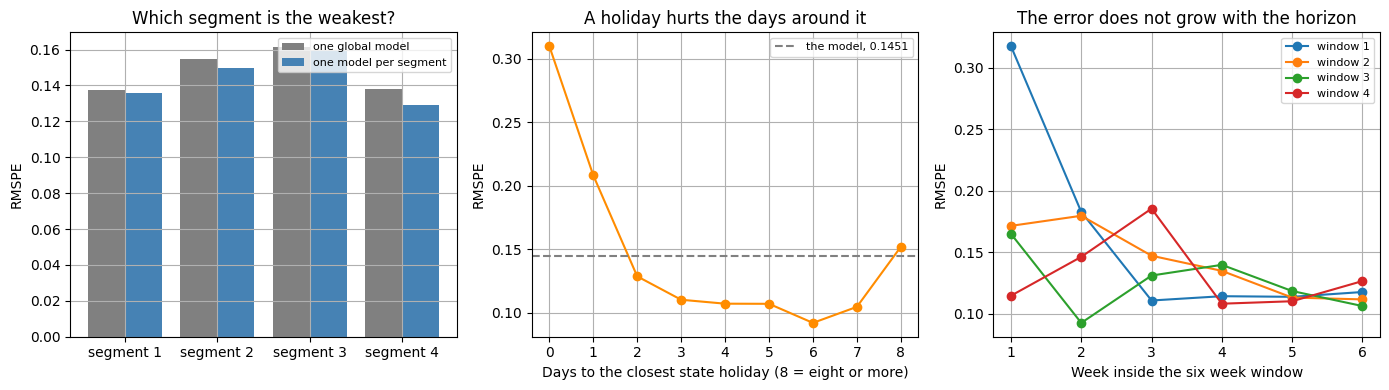

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

segment_table = both(scored, "segment")
x = np.arange(segment_table.height)
axes[0].bar(x - 0.2, segment_table["global"].to_numpy(), 0.4, label="one global model",
            color="gray")
axes[0].bar(x + 0.2, segment_table["segmented"].to_numpy(), 0.4, label="one model per segment",
            color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"segment {s}" for s in segment_table["segment"].to_list()])
axes[0].set_ylabel("RMSPE")
axes[0].set_title("Which segment is the weakest?")
axes[0].legend(fontsize=8)

gap_table = by(context.with_columns(pl.col("holiday_gap").clip(upper_bound=8)), "holiday_gap")
axes[1].plot(gap_table["holiday_gap"].to_list(), gap_table["rmspe"].to_list(),
             marker="o", color="darkorange")
axes[1].axhline(0.1451, color="gray", linestyle="--", label="the model, 0.1451")
axes[1].set_xlabel("Days to the closest state holiday (8 = eight or more)")
axes[1].set_ylabel("RMSPE")
axes[1].set_title("A holiday hurts the days around it")
axes[1].legend(fontsize=8)

week_table = (by(window_week, ["fold", "week_in_window"])
              .pivot(on="fold", index="week_in_window", values="rmspe")
              .sort("week_in_window"))
for column in [c for c in week_table.columns if c != "week_in_window"]:
    axes[2].plot(week_table["week_in_window"].to_list(), week_table[column].to_list(),
                 marker="o", label=f"window {column}")
axes[2].set_xlabel("Week inside the six week window")
axes[2].set_ylabel("RMSPE")
axes[2].set_title("The error does not grow with the horizon")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


## The ranked list of failure modes

This is the output of the notebook. The order is by how much error sits on the
group, not by how interesting it is.

| # | Failure mode | Size | What we would build |
|---|---|---|---|
| 1 | The model cannot see the closed days around it. A day after a closed day scores 0.187 and a day before one 0.171, against 0.123 for a normal day. | 38% of the rows, 57.5% of the squared error | `open_yesterday`, `open_tomorrow`, days since the last closed day, days to the next one, and days to the closest state holiday. All are known six weeks ahead. |
| 2 | The feasts that move with Easter. The carnival week scores 0.335 and the week before Easter 0.213. Two carnival days alone carry 47% of the hardest window. | Rosenmontag alone carries 14.2% of the whole error | The signed distance to Easter, and a flag for Rosenmontag and the day after it. |
| 3 | A store that has just come back from a renovation. The block 30 to 59 days after the first day back scores 0.265 against 0.127 in the next block. | 2,515 rows, about 1.6% | Days since the store reopened, and a store average that only counts the days since then. |
| 4 | Segment 3 is the weakest group, 0.1595 against 0.1290 for segment 4, and it carries more error than its share of rows. | 28% of the rows, 33% of the error | Nothing directly. Every new feature is measured per segment, and this segment decides whether it stays. |
| 5 | The start of the month, days 1 to 5, scores 0.178 against 0.116 for days 6 to 10. | 13% of the rows | A day-of-month feature that is not only the raw number: a flag for the first days, and the distance to the start of the month. |
| 6 | The model predicts about 1.3 percent too low, evenly in every segment. | every row | One multiplicative correction, fitted on validation. Step 9. A correction per segment is unlikely to add anything. |

Three things are **not** on the list, and it is worth saying why.

**Bad stores.** They exist, but they are not stable. A store that fails in one
window is mostly fine in the next, so there is nothing to learn from a list of
them.

**Store type and assortment.** The small types kept their advantage after the
split. Nothing is broken there.

**Weekday and promotion position as separate features.** They looked strong on
their own, but they are almost the same rows as item 1. Building them as
separate features would count one effect three times.

### What comes next

Item 1 is the whole first job of the next notebook: a small family of features
built around the closed days. Item 2 is the second, and it is cheap, because
Easter is a lookup table.

Both must be measured the same way as everything else in this project: four
windows, three seeds, and a win on every window before we keep them. Notebook 03
is the reminder. A pattern this clear in the error can still fail to help the
model, and only the folds decide.
